# 导入模块

In [61]:
import numpy as np
import xarray as xr
from netCDF4 import Dataset
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter
import metpy
import project
import cartopy.crs as ccrs
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import os

import matplotlib.colors as mcolors
from collections import defaultdict
import rain_cmap_levels


from wrf import getvar, interplevel

# 文件名处理和日期分类

In [ ]:
file_path = r'wrf_data\3'
file_list = os.listdir(file_path)
file_list = [f for f in file_list if f.startswith("wrfout")]

# 按时间排序（非常重要）
file_list = sorted(file_list)
file_groups = defaultdict(list)

for filename in file_list:
    parts = filename.split("_")
    month_day = parts[2][5:]
    hour = parts[3]
    domain_part = parts[1]  # ✅ 这里提取 d01 / d02
    file_groups[month_day].append(filename)
    
file_name_24 = file_groups['07-24']
file_name_25 = file_groups['07-25']
file_name_26 = file_groups['07-26']
file_name_27 = file_groups['07-27']
file_name_28 = file_groups['07-28']

file_name_25_d01 = file_name_25[:24]
file_name_25_d02 = file_name_25[24:48]
file_name_26_d01 = file_name_26[:24]
file_name_26_d02 = file_name_26[24:48]
file_name_26_d01 = file_name_26[:24]
file_name_26_d02 = file_name_26[24:48]
file_name_27_d01 = file_name_27[:24]
file_name_27_d02 = file_name_27[24:48]
file_name_28_d01 = [file_name_28[0]]
file_name_28_d02 = [file_name_28[1]] 

day_d01 = [file_name_25_d01, file_name_26_d01, file_name_27_d01, file_name_28_d01]
day_d02 = [file_name_25_d02, file_name_26_d02, file_name_27_d02, file_name_28_d02]

# 计算d01区域3天24小时降水

In [69]:
# --- 1. 预先初始化容器 ---
# 我们先读一个文件来获取网格形状 (nj, ni)
temp_nc = Dataset(os.path.join(file_path, day_d01[0][0]))
temp_rain = getvar(temp_nc, "RAINC")
shape_2d = temp_rain.shape  # 得到 (南屏方向格点数, 西东方向格点数)
temp_nc.close()

# 创建一个空的 numpy 数组来存 3 天的数据: [时间, 纬度, 经度]
# 因为 len(day_d01) 是 4，循环 3 次，所以第一维是 3
rain_24h_total_d01 = np.zeros((len(day_d01) - 1, shape_2d[0], shape_2d[1]))

# --- 2. 开始循环计算 ---
for i in range(len(day_d01) - 1):
    start_filename = day_d01[i][0]
    end_filename = day_d01[i + 1][0]
    
    path_start = os.path.join(file_path, start_filename)
    path_end = os.path.join(file_path, end_filename)
    
    nc_start = Dataset(path_start)
    nc_end = Dataset(path_end)
    
    # 获取两个时间点的累积降水
    r_start = getvar(nc_start, "RAINC") + getvar(nc_start, "RAINNC")
    r_end = getvar(nc_end, "RAINC") + getvar(nc_end, "RAINNC")
    
    # 存入容器
    # 注意：wrf-python 返回的是 DataArray，相减后我们取其 .values 存入 numpy 数组
    rain_24h_total_d01[i, :, :] = (r_end - r_start).values
    
    print(f"成功计算第 {i+1} 个时段: {end_filename} 减去 {start_filename}")
    
    nc_start.close()
    nc_end.close()

成功计算第 1 个时段: wrfout_d01_2025-07-26_00_00_00 减去 wrfout_d01_2025-07-25_00_00_00
成功计算第 2 个时段: wrfout_d01_2025-07-27_00_00_00 减去 wrfout_d01_2025-07-26_00_00_00
成功计算第 3 个时段: wrfout_d01_2025-07-28_00_00_00 减去 wrfout_d01_2025-07-27_00_00_00


# 计算d02区域3天24小时降水

In [70]:
# --- 1. 预先初始化容器 ---
# 我们先读一个文件来获取网格形状 (nj, ni)
temp_nc = Dataset(os.path.join(file_path, day_d02[0][0]))
temp_rain = getvar(temp_nc, "RAINC")
shape_2d = temp_rain.shape  # 得到 (南屏方向格点数, 西东方向格点数)
temp_nc.close()

# 创建一个空的 numpy 数组来存 3 天的数据: [时间, 纬度, 经度]
# 因为 len(day_d02) 是 4，循环 3 次，所以第一维是 3
rain_24h_total_d02 = np.zeros((len(day_d02) - 1, shape_2d[0], shape_2d[1]))

# --- 2. 开始循环计算 ---
for i in range(len(day_d02) - 1):
    start_filename = day_d02[i][0]
    end_filename = day_d02[i + 1][0]
    
    path_start = os.path.join(file_path, start_filename)
    path_end = os.path.join(file_path, end_filename)
    
    nc_start = Dataset(path_start)
    nc_end = Dataset(path_end)
    
    # 获取两个时间点的累积降水
    r_start = getvar(nc_start, "RAINC") + getvar(nc_start, "RAINNC")
    r_end = getvar(nc_end, "RAINC") + getvar(nc_end, "RAINNC")
    
    # 存入容器
    # 注意：wrf-python 返回的是 DataArray，相减后我们取其 .values 存入 numpy 数组
    rain_24h_total_d02[i, :, :] = (r_end - r_start).values
    
    print(f"成功计算第 {i+1} 个时段: {end_filename} 减去 {start_filename}")
    
    nc_start.close()
    nc_end.close()

成功计算第 1 个时段: wrfout_d02_2025-07-26_00_00_00 减去 wrfout_d02_2025-07-25_00_00_00
成功计算第 2 个时段: wrfout_d02_2025-07-27_00_00_00 减去 wrfout_d02_2025-07-26_00_00_00
成功计算第 3 个时段: wrfout_d02_2025-07-28_00_00_00 减去 wrfout_d02_2025-07-27_00_00_00


# 读取两个区域的经纬度和投影信息

In [ ]:
file_path_d01 = 'wrf_data\index_1\wrfout_d01_2025-07-25_20_00_00.nc'
ncfile = Dataset(file_path_d01)
ds_d01 = xr.open_dataset(file_path_d01)
crs_d01 = project.get_projection(ds_d01)

z = getvar(ncfile, "z", units="dm")  
pres = getvar(ncfile, "pressure") 
z_500  = interplevel(z, pres, 500)
lon_2d_d01,lat_2d_d01 = z_500['XLONG'], z_500['XLAT']

file_path_d02 = 'wrf_data\index_1\wrfout_d02_2025-07-25_20_00_00.nc'
ncfile_d02 = Dataset(file_path_d02)
ds_d02 = xr.open_dataset(file_path_d02)
crs_d02 = project.get_projection(ds_d02)

z_d02 = getvar(ncfile_d02, "z", units="dm")
pres_d02 = getvar(ncfile_d02, "pressure")
z_500_d02 = interplevel(z_d02, pres_d02, 500)
lon_2d_d02,lat_2d_d02 = z_500_d02['XLONG'], z_500_d02['XLAT']

# d01区域绘图

D02 数据检查: Max1=287.0980529785156, Max2=284.5369873046875, Max3=388.89154052734375


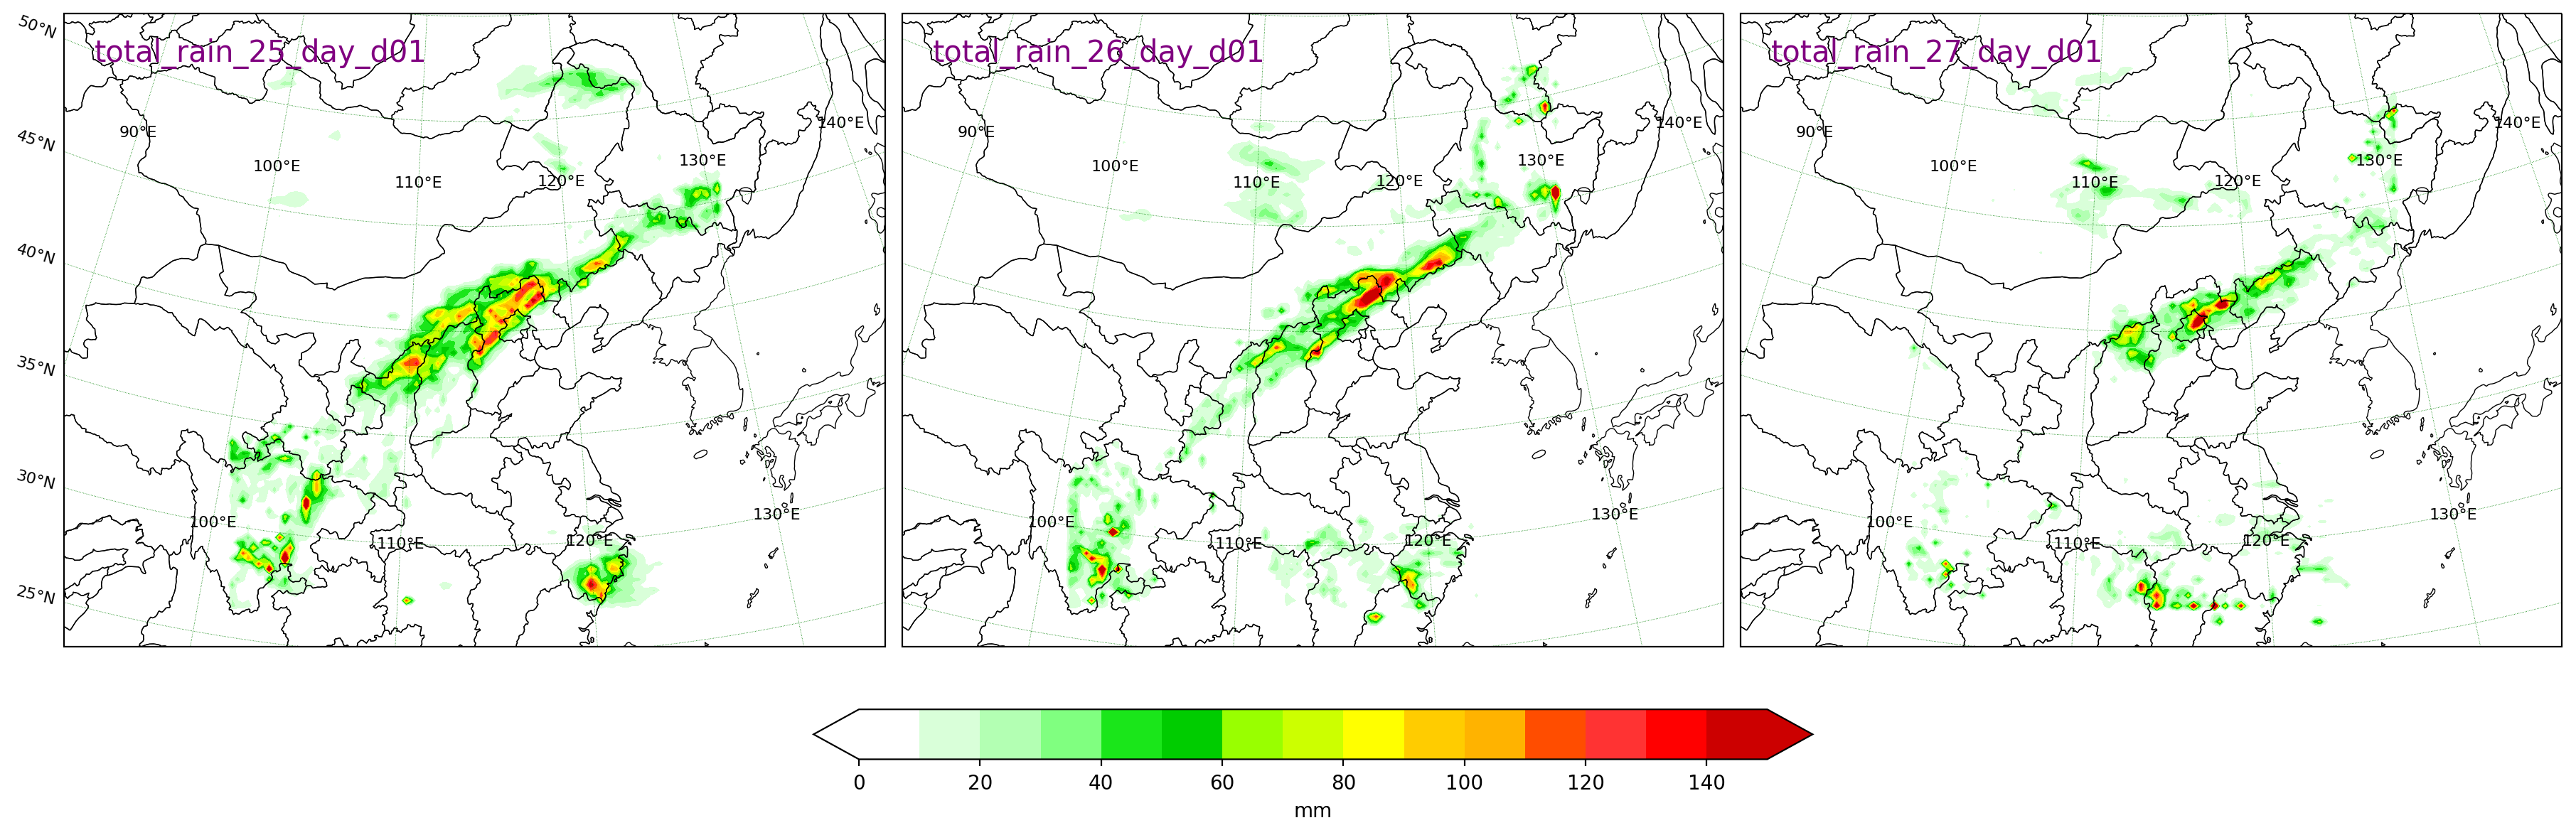

In [ ]:
# 1. 关闭共享坐标轴，避免子图干扰
fig, axarray = plt.subplots(1, 3, figsize=(18, 6), 
                            constrained_layout=True, dpi=200, 
                            subplot_kw={'projection': crs_d01})
axlist = axarray.flatten()

# 定义统一的色阶，防止数据太小不出图
clevs = np.arange(0, 151, 10) 

for i in range(3):
    ax = axlist[i]
    
    # 2. 绘制背景和范围
    project.plot_background(lon_2d_d01.min(), lon_2d_d01.max(), 
                            lat_2d_d01.min(), lat_2d_d01.max(), ax)
    
    # 3. 绘图：注意 transform 必须用 PlateCarree
    im = ax.contourf(lon_2d_d01, lat_2d_d01, rain_24h_total_d01[i, :, :],
                     levels=clevs,
                     cmap=rain_cmap_levels.cmap, 
                     transform=ccrs.PlateCarree(),
                     extend='both')
    
    # 显式强制设置坐标范围，防止第一个子图劫持了范围
    ax.set_extent([lon_2d_d01.min(), lon_2d_d01.max(), 
                   lat_2d_d01.min(), lat_2d_d01.max()], 
                  crs=ccrs.PlateCarree())
    
    # 4. 网格线配置
    gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                      linewidth=0.3, linestyle=':', color='green')
    gl.top_labels = False
    gl.right_labels = False
    if i > 0: gl.left_labels = False # 保持美观，只留最左侧标签
    gl.xlabel_style = {'size': 8}
    gl.ylabel_style = {'size': 8}
    ax.text(lon_2d_d01.min()-8, lat_2d_d01.max()-4,f"total_rain_{i+25}_day_d01",color='purple',transform=ccrs.PlateCarree(),fontsize=15)
    

# 5. 添加颜色条
fig.colorbar(im, ax=axlist, orientation='horizontal', shrink=0.4, pad=0.08, label='mm')

plt.savefig('D:\\python_atmosphere\\mesoscale_homework\\24小时降水\\huanliu3_do1.pdf', dpi=200)

# d02区域绘图

D02 数据检查: Max1=287.0980529785156, Max2=284.5369873046875, Max3=388.89154052734375


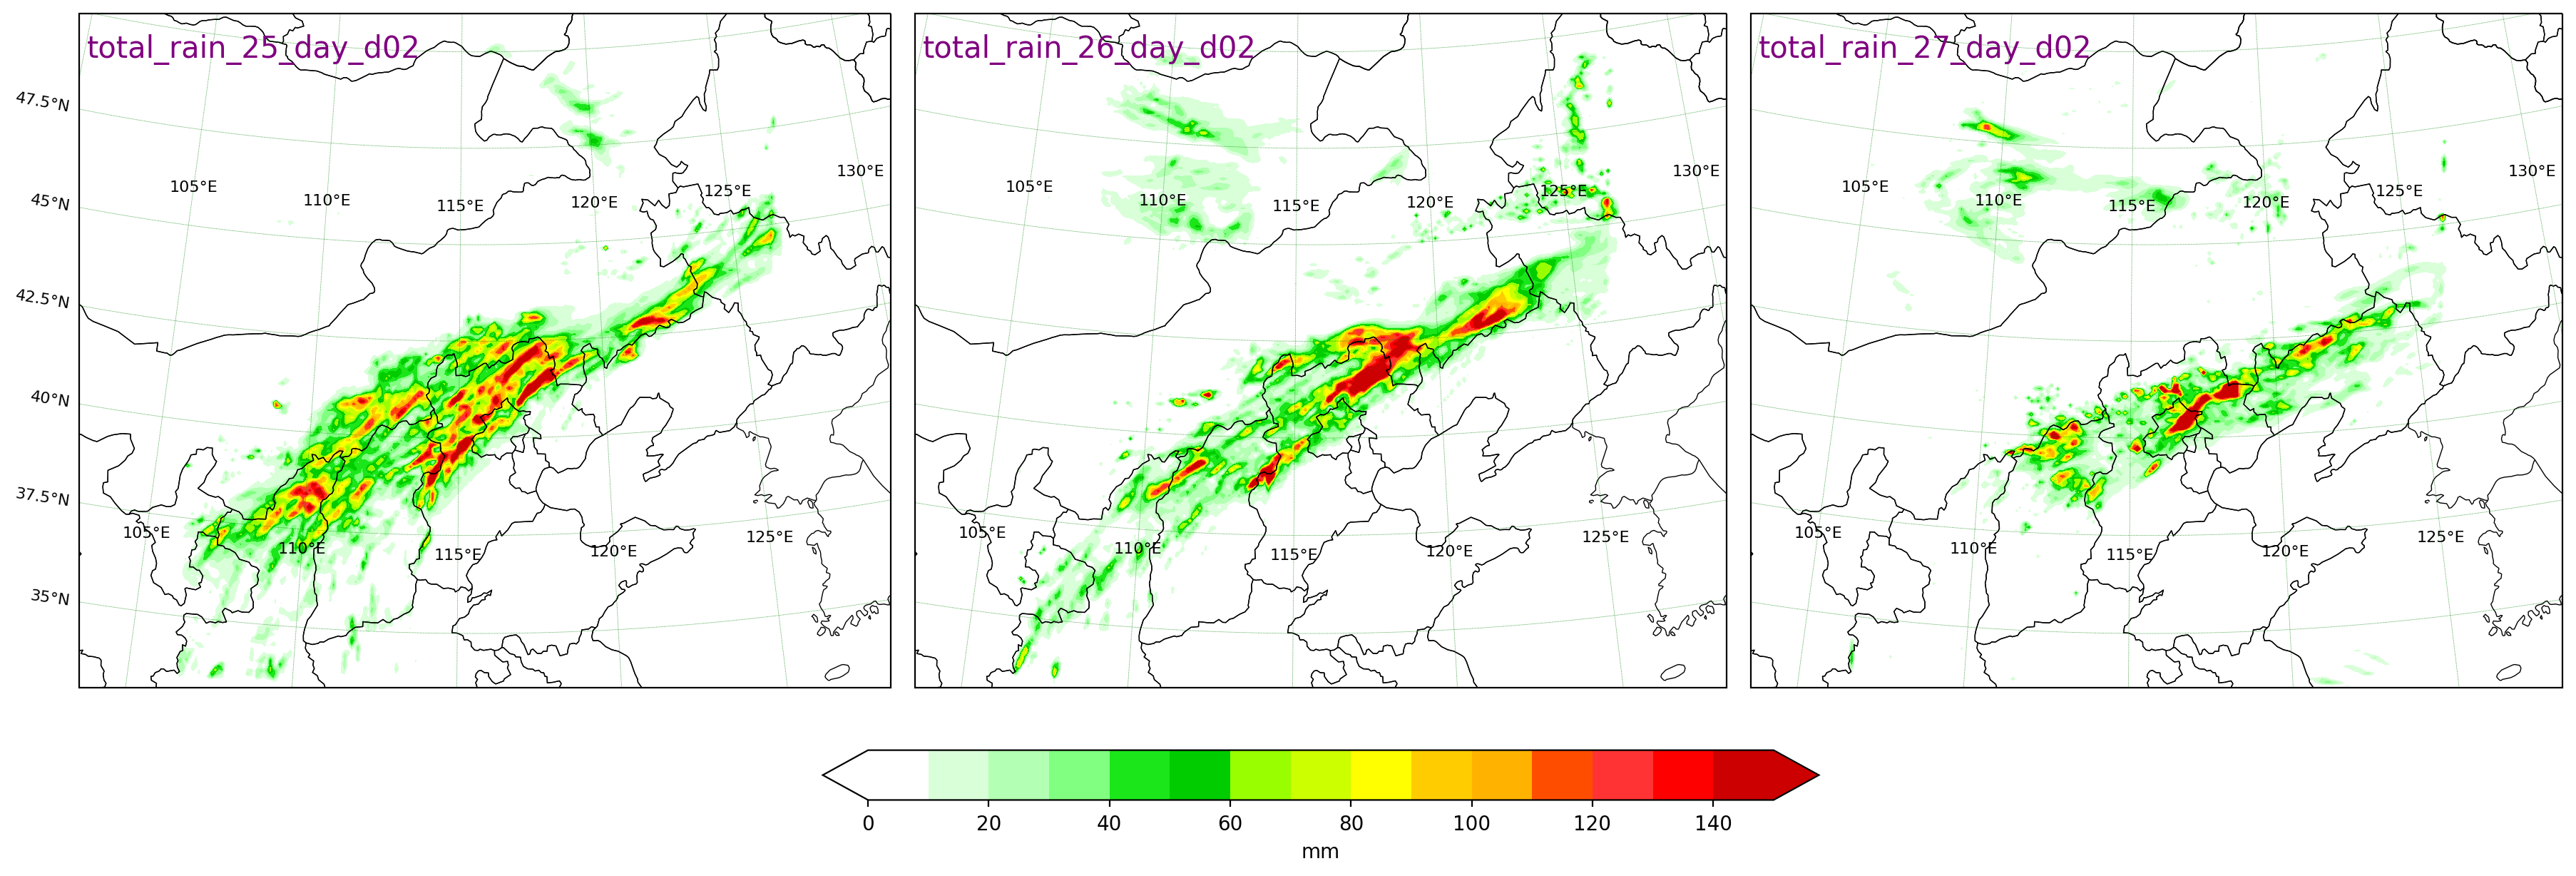

In [73]:
# 建议先运行这一行，确保数据确实存在
print(f"D02 数据检查: Max1={rain_24h_total_d02[0].max()}, Max2={rain_24h_total_d02[1].max()}, Max3={rain_24h_total_d02[2].max()}")

# 1. 关闭共享坐标轴，避免子图干扰
fig, axarray = plt.subplots(1, 3, figsize=(18, 6), 
                            constrained_layout=True, dpi=200, 
                            subplot_kw={'projection': crs_d02})
axlist = axarray.flatten()

# 定义统一的色阶，防止数据太小不出图
clevs = np.arange(0, 151, 10) 

for i in range(3):
    ax = axlist[i]
    
    # 2. 绘制背景和范围
    project.plot_background(lon_2d_d02.min(), lon_2d_d02.max(), 
                            lat_2d_d02.min(), lat_2d_d02.max(), ax)
    
    # 3. 绘图：注意 transform 必须用 PlateCarree
    im = ax.contourf(lon_2d_d02, lat_2d_d02, rain_24h_total_d02[i, :, :],
                     levels=clevs,
                     cmap=rain_cmap_levels.cmap, 
                     transform=ccrs.PlateCarree(),
                     extend='both')
    
    # 显式强制设置坐标范围，防止第一个子图劫持了范围
    ax.set_extent([lon_2d_d02.min(), lon_2d_d02.max(), 
                   lat_2d_d02.min(), lat_2d_d02.max()], 
                  crs=ccrs.PlateCarree())
    
    # 4. 网格线配置
    gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                      linewidth=0.3, linestyle=':', color='green')
    gl.top_labels = False
    gl.right_labels = False
    if i > 0: gl.left_labels = False # 保持美观，只留最左侧标签
    gl.xlabel_style = {'size': 8}
    gl.ylabel_style = {'size': 8}
    ax.text(lon_2d_d02.min()-3.5, lat_2d_d02.max()-1.5,f"total_rain_{i+25}_day_d02",color='purple',transform=ccrs.PlateCarree(),fontsize=15)
# 5. 添加颜色条
fig.colorbar(im, ax=axlist, orientation='horizontal', shrink=0.4, pad=0.08, label='mm')
plt.savefig('D:\\python_atmosphere\\mesoscale_homework\\24小时降水\\huanliu3_do2.pdf', dpi=200)
